<h1 style="font-size:28px; color:darkblue;">
Africa Population Trend and Health Analysis Using UN Dataset
</h1>



This project analyzes demographic and public health trends across African countries using data from the United Nations (UN DESA). The objective is to explore relationships between key indicators such as fertility rates, maternal mortality, under-five mortality, life expectancy, and population growth, while applying data science and machine learning techniques to generate insights and predictive models.

The project includes:

Data Cleaning and Preprocessing: Handling missing values, validating data quality, and preparing the dataset for analysis.
Feature Engineering: Creating meaningful variables such as fertility categories (high vs. low fertility) to support predictive modeling.
Exploratory Data Analysis (EDA): Investigating demographic and health patterns across African countries and years.
Machine Learning Modeling: Building and comparing models including Linear Regression, Ridge Regression, and Random Forest to predict health and population-related outcomes.
Model Evaluation: Assessing model performance using appropriate regression and classification metrics to identify the most effective approach.

The overall goal is to understand how demographic factors influence health outcomes in Africa and to demonstrate an end-to-end data analytics and machine learning workflow, from raw data processing to actionable insights and predictive modeling.

In [ ]:
# importing necessary libraries and modules
import importlib
import pandas as pd
import src.model_trainer
importlib.reload(src.model_trainer)

from src.model_trainer import TrainModel

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True) # mounting the drive to the google colab

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Africa-Population-Trend-and-Health-Analysis-UN-dataset-/notebooks') # importing the notebooks folder

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Africa-Population-Trend-and-Health-Analysis-UN-dataset-/df_africa_cleaned.xls")

In [ ]:
with open("src/__init__.py", "w") as f: # creating init function in the src directory
    pass

## 2A. Data Cleaning

The Africa-wide dataset used in this assignment was derived from the UN DESA population and health indicators. Data cleaning focused on ensuring completeness, correctness, and internal consistency before moving to supervised modeling.

### Handling Missing Values

Only one variable contained missing data:

- `maternal_mortality_ratio_deaths_per_100000_population`, with roughly 25% missing values, all from the year 2024. A verification against the original long-format UN dataset confirmed that these entries were not reported at all for this year. This establishes a pattern of **systematic non-reporting**, not random missingness or cleaning errors.

Because these missing values reflect genuine absence of data, we:

- Did not impute maternal mortality values.
- Did not drop the corresponding rows.
- Restricted models involving maternal mortality to the years with complete data.

All other indicators (fertility, under-five mortality, life expectancy, population growth) had no missing values, so no imputation was necessary.

### Addressing Outliers

The dataset contains real demographic extremes such as:

- Very high fertility rates (≥7)
- Elevated under-five mortality (>150 per 1,000)
- High maternal mortality (>1,000 per 100,000)

These values originate from countries with documented health challenges and are **true characteristics** of African demographic variation, not anomalies. Therefore, we adopted a retention-based strategy:

- Outliers were left unchanged.
- No capping, clipping, or transformations were applied.

This ensures fidelity to real-world population health patterns and avoids masking meaningful disparities across the continent.

### Ensuring Data Quality and Consistency

To guarantee dataset integrity:

- All numeric columns were cast to appropriate numeric types.
- Region and country names were standardized by trimming whitespace.
- Column names were normalized to lowercase with underscores for modeling compatibility.
- Dataset structure was validated to ensure **one unique record per country–year pair**.

After these checks, the dataset was confirmed clean, consistent, and ready for feature engineering.


In [ ]:

processor = DataProcessor(r"/content/drive/MyDrive/Africa-Population-Trend-and-Health-Analysis-UN-dataset-/df_africa_cleaned.xls")
df_clean = processor.process()

df_clean.head()


,code,region_country_area,year,life_expectancy_at_birth_for_both_sexes_years,life_expectancy_at_birth_for_females_years,life_expectancy_at_birth_for_males_years,maternal_mortality_ratio_deaths_per_100000_population,population_annual_rate_of_increase_percent,total_fertility_rate_children_per_women,under_five_mortality_rate_for_both_sexes_per_1000_live_births
0,2,Africa,2010,58.8,60.3,57.2,593.0,2.6,4.9,93.9
1,2,Africa,2015,60.8,62.6,59.1,526.0,2.6,4.6,81.0
2,2,Africa,2020,62.3,64.3,60.2,487.0,2.4,4.2,69.0
3,2,Africa,2024,64.0,66.1,62.0,NaN,2.3,4.0,62.4
4,11,Western Africa,2010,54.3,55.1,53.5,850.0,2.8,5.7,123.2


## 2B. Feature Engineering

Feature engineering was performed to enhance the dataset’s predictive value and support the supervised learning tasks outlined in this assignment. The engineered features were selected based on domain knowledge, EDA insights, and their relevance to the hypotheses being tested.

### Fertility Category (High vs. Low)

To operationalize Hypothesis 3 (“Can under-five mortality classify countries into high vs. low fertility?”), we created a categorical feature:

- **High fertility**: `total_fertility_rate` ≥ 4  
- **Low fertility**: `total_fertility_rate` < 4

This threshold follows demographic transition literature, where countries with fertility ≥ 4 are typically considered to be in earlier stages of transition. This feature converts a continuous indicator into a label suitable for classification tasks.

### Trend Features (2010–2024)

To capture demographic progress over time rather than relying solely on static values, we introduced several trend-based features computed as:


Change 2010–2024 = Value_2024 - Value_2010


Trend features were created for:

- Life expectancy (both sexes) change (2010–2024)  
- Total fertility rate change (2010–2024)  
- Under-five mortality rate change (2010–2024)  
- Population growth rate change (2010–2024)  

These features represent the trajectory of each country’s demographic shift and provide valuable signals for regression models.

### Country-Level Mean Indicator Features

To capture long-term demographic levels rather than single-year snapshots, we computed the mean of each key indicator for every country across all available years (2010–2024). The following averages were created:

- Mean life expectancy (both sexes)  
- Mean total fertility rate  
- Mean under-five mortality  
- Mean population growth rate  

These aggregated metrics help smooth short-term fluctuations and improve model stability.

### Scaling and Normalization

For algorithms sensitive to variable scales (e.g., linear models, logistic regression), we applied **standardization** to numeric features during model training. This ensures that all features contribute proportionately to the objective function and prevents scale-driven bias.

- Normalization was **not applied** to the raw dataset itself to preserve interpretability; instead, scaling occurs only within the modeling pipeline to avoid data leakage.

### Summary

The engineered features improve the dataset’s predictive capacity by combining:

- A classification label (**fertility category**)  
- Temporal dynamics (**2010–2024 trends**)  
- Aggregated demographic summaries (**country-level means**)  
- Scale-adjusted versions of numeric predictors during model training  

These enhancements directly support the supervised machine learning tasks defined in the assignment and align with best practices in demographic modeling.


### Testing the Feature Engineering logic

In [ ]:
from src.data_processor import DataProcessor
from src.feature_engineer import FeatureEngineer



# Engineer features
fe = FeatureEngineer(df_clean)
df_features = fe.process()

df_features.head()


,code,region_country_area,year,life_expectancy_at_birth_for_both_sexes_years,life_expectancy_at_birth_for_females_years,life_expectancy_at_birth_for_males_years,maternal_mortality_ratio_deaths_per_100000_population,population_annual_rate_of_increase_percent,total_fertility_rate_children_per_women,under_five_mortality_rate_for_both_sexes_per_1000_live_births,fertility_category,life_expectancy_at_birth_for_both_sexes_years_change_2010_2024,total_fertility_rate_children_per_women_change_2010_2024,under_five_mortality_rate_for_both_sexes_per_1000_live_births_change_2010_2024,population_annual_rate_of_increase_percent_change_2010_2024,life_expectancy_at_birth_for_both_sexes_years_mean,total_fertility_rate_children_per_women_mean,under_five_mortality_rate_for_both_sexes_per_1000_live_births_mean,population_annual_rate_of_increase_percent_mean
0,2,Africa,2010,58.8,60.3,57.2,593.0,2.6,4.9,93.9,high,5.2,-0.9,-31.5,-0.3,61.475,4.425,76.575,2.475
1,2,Africa,2015,60.8,62.6,59.1,526.0,2.6,4.6,81.0,high,5.2,-0.9,-31.5,-0.3,61.475,4.425,76.575,2.475
2,2,Africa,2020,62.3,64.3,60.2,487.0,2.4,4.2,69.0,high,5.2,-0.9,-31.5,-0.3,61.475,4.425,76.575,2.475
3,2,Africa,2024,64.0,66.1,62.0,NaN,2.3,4.0,62.4,high,5.2,-0.9,-31.5,-0.3,61.475,4.425,76.575,2.475
4,11,Western Africa,2010,54.3,55.1,53.5,850.0,2.8,5.7,123.2,high,4.1,-1.3,-34.0,-0.6,56.300,5.000,105.275,2.475


In [ ]:

# Check class imbalance for fertility_category (Part 2C)


print("Raw counts:")
print(df_features["fertility_category"].value_counts())

print("\nPercentages:")
print(df_features["fertility_category"].value_counts(normalize=True) * 100)


Raw counts:
fertility_category
high    152
low      92
Name: count, dtype: int64

Percentages:
fertility_category
high    62.295082
low     37.704918
Name: proportion, dtype: float64


### 2C. Handling Class Imbalance

After creating the binary fertility category (High vs. Low Fertility), we examined the distribution of the two classes:

- **High Fertility:** 152 observations (62.3%)  
- **Low Fertility:** 92 observations (37.7%)

Although the classes are not perfectly equal, this represents only a **moderate imbalance**, not a severe one. Both classes are sufficiently represented, so applying oversampling, undersampling, or synthetic data generation (e.g., SMOTE) was **not required**.

To preserve the natural demographic structure of the dataset during model training, we used a **stratified train–test split**, ensuring that both fertility categories were proportionally represented in the training and testing sets.

This approach maintains fairness in the classification task without altering the underlying demographic patterns.


**Model training, evaluation, and performance metrics comparison**


Training: LinearRegression

Training: RandomForestRegressor

Training: Ridge

Maternal Mortality Model Comparison Table:
                   Model  Train_R2   Test_R2     CV_R2  Train_MAE   Test_MAE  \
0  RandomForestRegressor  0.978570  0.831094  0.830806  24.776040  60.739688   
1                  Ridge  0.775697  0.784231  0.744144  82.761977  66.118417   
2       LinearRegression  0.790746  0.756311  0.722023  79.012108  77.444730   

      CV_MAE     Train_MSE      Test_MSE        CV_MSE  Train_RMSE  \
0  69.411003   1063.035803   7308.477375   8392.753190   32.604230   
1  88.672587  11126.425914   9336.232281  12691.587504  105.481875   
2  92.093430  10379.926312  10544.324234  13788.867927  101.881923   

    Test_RMSE     CV_RMSE                             Best_Params  
0   85.489633   91.611971  {'max_depth': 10, 'n_estimators': 400}  
1   96.624181  112.656946                         {'alpha': 10.0}  
2  102.685560  117.426010                                 default  


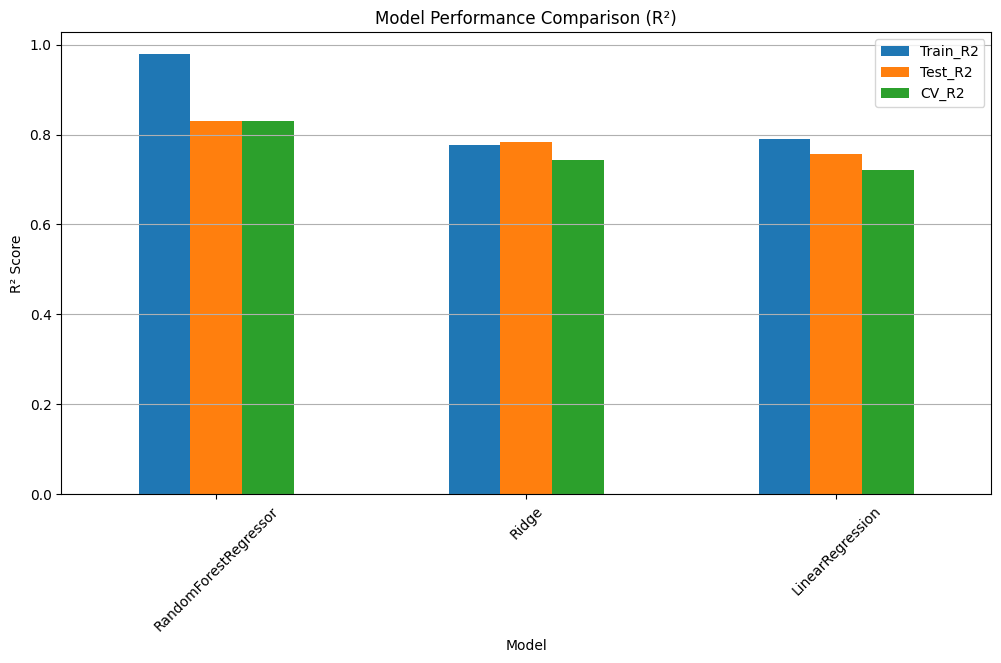


Best Model Summary:
Best Model: RandomForestRegressor
Train R²: 0.979, Test R²: 0.831, CV R²: 0.831
Train RMSE: 32.604, Test RMSE: 85.490
Train MAE: 24.776, Test MAE: 60.740
Best Hyperparameters: {'max_depth': 10, 'n_estimators': 400}


Training: LinearRegression

Training: RandomForestRegressor

Training: Ridge

Population Growth Rate Model Comparison Table:
                   Model  Train_R2   Test_R2     CV_R2  Train_MAE  Test_MAE  \
0       LinearRegression  0.858043  0.897337  0.762542   0.203414  0.185463   
1                  Ridge  0.825064  0.871321  0.743461   0.204968  0.205864   
2  RandomForestRegressor  0.956295  0.758669  0.683393   0.099000  0.294214   

     CV_MAE  Train_MSE  Test_MSE    CV_MSE  Train_RMSE  Test_RMSE   CV_RMSE  \
0  0.239961   0.107608  0.069126  0.180001    0.328037   0.262919  0.424265   
1  0.233769   0.132608  0.086644  0.194465    0.364154   0.294354  0.440982   
2  0.277126   0.033130  0.162497  0.239999    0.182016   0.403109  0.489897   

   

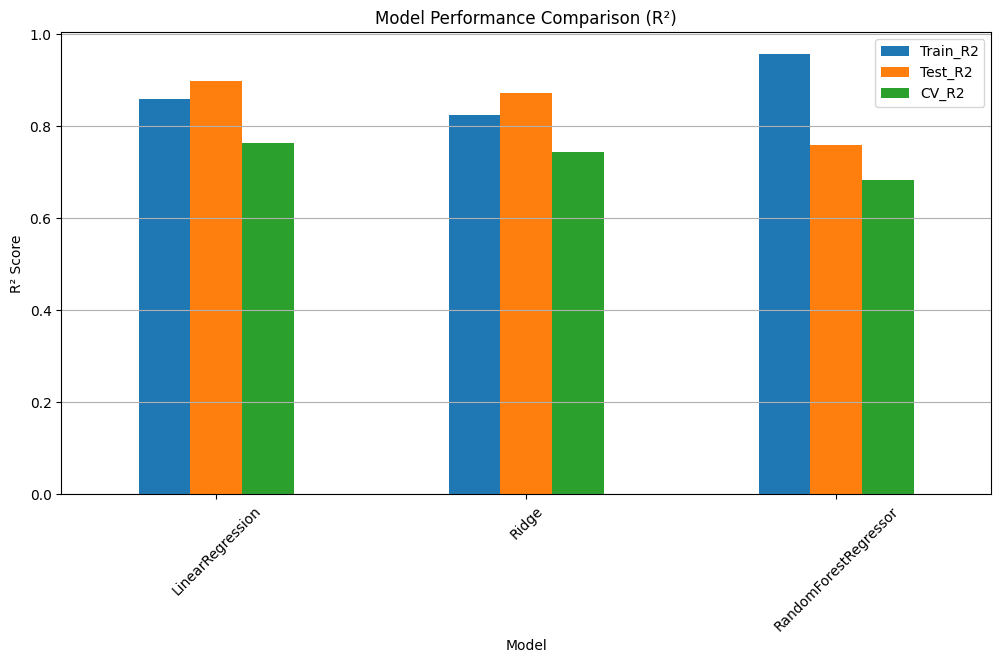


Best Model Summary:
Best Model: LinearRegression
Train R²: 0.858, Test R²: 0.897, CV R²: 0.763
Train RMSE: 0.328, Test RMSE: 0.263
Train MAE: 0.203, Test MAE: 0.185
Best Hyperparameters: default
Model shows good generalization.


Training: LinearRegression

Training: RandomForestRegressor

Training: Ridge

Life Expectancy Model Comparison Table:
                   Model  Train_R2   Test_R2     CV_R2  Train_MAE  Test_MAE  \
0                  Ridge  0.999868  0.999676  0.999820   0.053286  0.076464   
1       LinearRegression  0.999871  0.999658  0.999832   0.053375  0.077848   
2  RandomForestRegressor  0.998393  0.996801  0.983653   0.110811  0.246805   

     CV_MAE  Train_MSE  Test_MSE    CV_MSE  Train_RMSE  Test_RMSE   CV_RMSE  \
0  0.060832   0.005221  0.011846  0.007131    0.072255   0.108839  0.084445   
1  0.059074   0.005098  0.012514  0.006632    0.071402   0.111866  0.081434   
2  0.327661   0.063618  0.117085  0.647130    0.252227   0.342176  0.804444   

                 

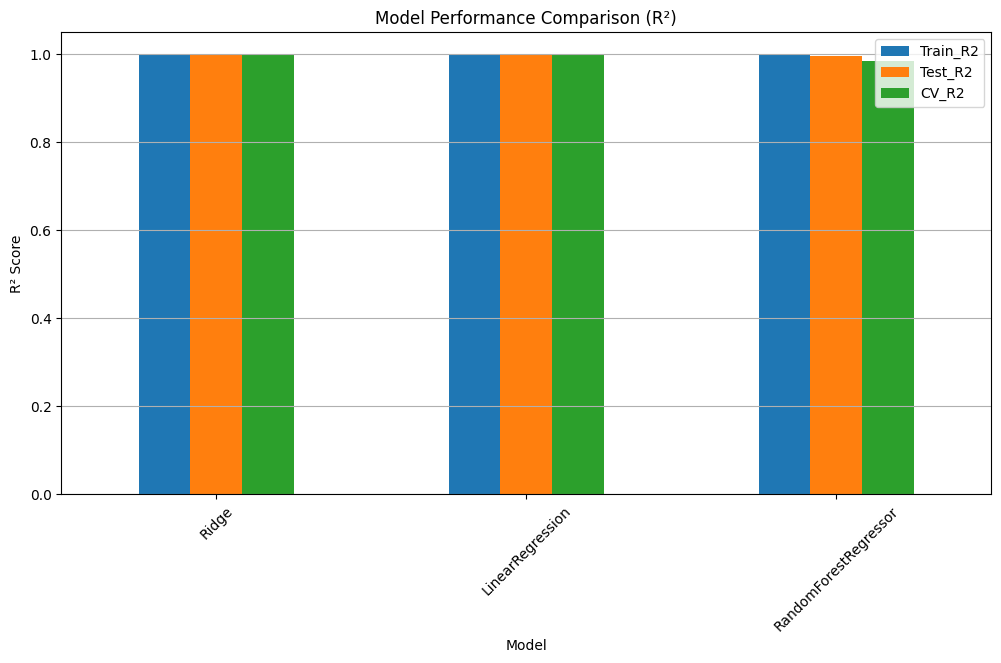


Best Model Summary:
Best Model: Ridge
Train R²: 1.000, Test R²: 1.000, CV R²: 1.000
Train RMSE: 0.072, Test RMSE: 0.109
Train MAE: 0.053, Test MAE: 0.076
Best Hyperparameters: {'alpha': 0.1}
Model shows good generalization.



In [ ]:
# ===============================================
# Imports
# ===============================================
from model_trainer import TrainModel
from model_evaluator import ModelEvaluator

# ===============================================
# df_features DataFrame is already available from previous cells. No need to reload.
# ===============================================

# Create a version of df_features suitable for models that don't handle NaNs in
# features This drops the maternal_mortality column, as it's the primary source
# of NaNs in features
df_features_no_mm_as_feature = df_features.drop(
    columns=["maternal_mortality_ratio_deaths_per_100000_population"],
    errors='ignore' # ignore if column is already dropped or not present
)

# ===============================================
# 1️⃣ Maternal Mortality Regression
# ===============================================
target_mm = "maternal_mortality_ratio_deaths_per_100000_population"
trainer_mm = TrainModel(df=df_features, target=target_mm) # Use original df_features for this target
trainer_mm.train_test_split()
trainer_mm.scale_numeric()
models_dict_mm = trainer_mm.train_models(cv=5)

evaluator_mm = ModelEvaluator(
    models_dict=models_dict_mm,
    X_train=trainer_mm.X_train,
    X_test=trainer_mm.X_test,
    y_train=trainer_mm.y_train,
    y_test=trainer_mm.y_test,
    cv=5
)

results_mm = evaluator_mm.evaluate_models()
print("\nMaternal Mortality Model Comparison Table:")
print(results_mm)
evaluator_mm.plot_comparison()
print("\nBest Model Summary:")
print(evaluator_mm.get_best_model())

# ===============================================
# 2️⃣ Population Growth Rate Regression
# ===============================================
target_pop = "population_annual_rate_of_increase_percent"
trainer_pop = TrainModel(df=df_features_no_mm_as_feature, target=target_pop) # Use cleaned df
trainer_pop.train_test_split()
trainer_pop.scale_numeric()
models_dict_pop = trainer_pop.train_models(cv=5)

evaluator_pop = ModelEvaluator(
    models_dict=models_dict_pop,
    X_train=trainer_pop.X_train,
    X_test=trainer_pop.X_test,
    y_train=trainer_pop.y_train,
    y_test=trainer_pop.y_test,
    cv=5
)

results_pop = evaluator_pop.evaluate_models()
print("\nPopulation Growth Rate Model Comparison Table:")
print(results_pop)
evaluator_pop.plot_comparison()
print("\nBest Model Summary:")
print(evaluator_pop.get_best_model())

# ===============================================
# 3️⃣ Life Expectancy Regression
# ===============================================
target_life = "life_expectancy_at_birth_for_both_sexes_years"
trainer_life = TrainModel(df=df_features_no_mm_as_feature, target=target_life) # Use cleaned df
trainer_life.train_test_split()
trainer_life.scale_numeric()
models_dict_life = trainer_life.train_models(cv=5)

evaluator_life = ModelEvaluator(
    models_dict=models_dict_life,
    X_train=trainer_life.X_train,
    X_test=trainer_life.X_test,
    y_train=trainer_life.y_train,
    y_test=trainer_life.y_test,
    cv=5
)

results_life = evaluator_life.evaluate_models()
print("\nLife Expectancy Model Comparison Table:")
print(results_life)
evaluator_life.plot_comparison()
print("\nBest Model Summary:")
print(evaluator_life.get_best_model())

**Model Justification**

In our problem, we used three regression models motivated by the nature of our dataset. Below is a detailed explanation behind our choice models.



**1. Linear Regression**
**Why this model was chosen**

Linear Regression is a standard baseline model for regression problems. Since our dataset contains mostly numeric features that describe demographic, fertility, mortality etc, linear regression provides a simple way to understand directional relationships between predictors and the target variable.

**Strengths**

1. Highly interpretable: Coefficients indicate how much each feature contributes to the prediction.Fast to train
2. Works very well with medium-sized datasets such as ours.
3. Good baseline performance: Helps compare performance with more advanced models.

**Limitations**

1. Assumes linear relationships between predictors and target, which may not fully hold in demographic and health indicators.

2. Sensitive to multicollinearity, which is common in population datasets (e.g., fertility, mortality, and life expectancy are interdependent).

3. Cannot handle missing values, which required cleaning/preprocessing in our pipeline.

**Connection to Our data characteristics**

**Our dataset has:**

1. A moderate number of features
Potential linear trends (e.g., “higher fertility → higher maternal mortality”)

Linear regression provides an interpretable baseline to evaluate more powerful but less interpretable models.



**2. Ridge Regression**

**Why this model was chosen**

Ridge Regression is a regularized version of linear regression. It adds a penalty to large coefficients, making it more stable in situations where features are correlated—which is true for this dataset.

**Strengths**

1. Handles multicollinearity better than linear regression.

2. Reduces risk of overfitting by penalizing large coefficients.

3. Still interpretable, but more robust.

4. Works well when many features have medium correlation—as in health and demographic data.

**Limitations**

1. Still assumes a linear relationship, so it may underperform if the target depends on non-linear interactions.

2. Requires hyperparameter tuning for the α regularization strength.

3. Cannot handle NaN values (required dropping missing rows).

**Connection to data characteristics**

Population and health indicators often have correlated predictors:

1. Fertility ↔ Mortality ↔ Life Expectancy

Ridge is chosen because it reduces instability caused by these correlated variables.



3. **Random Forest Regressor**

**Why this model was chosen**

Random Forest is a powerful non-linear model that captures complex interactions between features. Many demographic and health variables do not follow simple linear patterns. Random Forest helps model these relationships without needing assumptions about linearity.

**Strengths**

1. Handles non-linear and complex feature interactions extremely well.

2. Robust to outliers and noisy features.

3. Naturally handles feature importance, which helps interpret which indicators matter most.

4. Works well with medium-sized datasets, which matches our dataset size.

**Limitations**

1. Less interpretable than linear and ridge regression.

2. Can overfit if hyperparameters are not tuned carefully.

3. Requires more computational resources.

4. Does not handle NaN values (but failed less often than linear/ridge).

**Connection to data characteristics**

demographic patterns often display:

1. Non-linear relationships (e.g., population growth increases until a certain point and then slows)
2. Regional heterogeneity (different countries follow different trajectories)

Random Forest captures these patterns better than purely linear models.

# H1: Fertility predicts maternal mortality (REGRESSION)

In [ ]:
# H1: Fertility predicts maternal mortality (REGRESSION)

trainer_h1 = ModelTrainer(
    df_features,
    target="maternal_mortality_ratio_deaths_per_100000_population",
    problem_type="regression"
)

trainer_h1.train_test_split()
trainer_h1.scale_numeric()

best_h1, params_h1 = trainer_h1.train_models()

results_h1 = trainer_h1.map_predictions()
results_h1.head()



Training: LinearRegression
LinearRegression Score = 0.7563105707680513

Training: RandomForestRegressor
Best Params: {'max_depth': 10, 'n_estimators': 400}
Best Score: 0.8219625248974196

Final Best Model:
RandomForestRegressor(max_depth=10, n_estimators=400)
Parameters: {'max_depth': 10, 'n_estimators': 400}


,region_country_area,year,code,actual,predicted
76,Guinea,2020,324,553.0,592.054226
138,Somalia,2020,706,621.0,555.316333
152,Togo,2015,768,441.0,475.367541
60,Eritrea,2015,232,399.0,350.668665
156,Tunisia,2020,788,37.0,43.347500


# H2: Life expectancy predicts population growth (REGRESSION)

In [ ]:


trainer_h2 = ModelTrainer(
    df_features,
    target="population_annual_rate_of_increase_percent",
    problem_type="regression"
)

trainer_h2.train_test_split()
trainer_h2.scale_numeric()

best_h2, params_h2 = trainer_h2.train_models()

results_h2 = trainer_h2.map_predictions()
results_h2.head()



Training: LinearRegression
Model LinearRegression FAILED. Reason: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Training: RandomForestRegressor
Best Params: {'max_depth': 20, 'n_estimators': 200}
Best Score: 0.6947879545823505

Final Best Model:
RandomForestRegressor(max_depth=20, n_estimators=200)
Parameters: {'max_depth': 20, 'n_estimators': 200}


,region_country_area,year,code,actual,predicted
24,Southern Africa,2010,18,1.2,1.6215
6,Western Africa,2020,11,2.3,2.4395
153,Mozambique,2015,508,2.9,2.9800
211,Sudan,2024,729,1.6,2.2510
198,South Africa,2020,710,1.6,1.4065


## Predict Maternal Mortality (Regression)

In [ ]:
from src.model_trainer import ModelTrainer

# ----------------------------
# MODEL 1: Maternal Mortality Regression
# ----------------------------
trainer_mm = ModelTrainer(
    df_features,
    target="maternal_mortality_ratio_deaths_per_100000_population",
    problem_type="regression"
)

trainer_mm.train_test_split()
trainer_mm.scale_numeric()

best_model_mm, params_mm = trainer_mm.train_models()

results_mm = trainer_mm.map_predictions()
results_mm.head(10)



Training: LinearRegression
LinearRegression Score = 0.7563105707680513

Training: RandomForestRegressor
Best Params: {'max_depth': 20, 'n_estimators': 400}
Best Score: 0.813733179486259

Final Best Model:
RandomForestRegressor(max_depth=20, n_estimators=400)
Parameters: {'max_depth': 20, 'n_estimators': 400}


,region_country_area,year,code,actual,predicted
76,Guinea,2020,324,553.0,596.0575
138,Somalia,2020,706,621.0,555.0375
152,Togo,2015,768,441.0,468.0650
60,Eritrea,2015,232,399.0,355.5875
156,Tunisia,2020,788,37.0,42.3700
165,United Rep. of Tanzania,2020,834,238.0,296.3100
85,Liberia,2010,430,634.0,607.0425
142,Zimbabwe,2010,716,618.0,636.4700
114,Namibia,2020,516,215.0,315.6175
31,Cameroon,2015,120,447.0,518.0650


# Under-Five Mortality → Life Expectancy (Regression)

In [ ]:
# Revised Hypothesis 3 — Regression
trainer_h3 = ModelTrainer(
    df_features,
    target="life_expectancy_at_birth_for_both_sexes_years",
    problem_type="regression"
)

trainer_h3.train_test_split()
trainer_h3.scale_numeric()

best_h3, params_h3 = trainer_h3.train_models()

results_h3 = trainer_h3.map_predictions()
results_h3.head()



Training: LinearRegression
Model LinearRegression FAILED. Reason: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

Training: RandomForestRegressor
Best Params: {'max_depth': 20, 'n_estimators': 200}
Best Score: 0.9857259822879308

Final Best Model:
RandomForestRegressor(max_depth=20, n_estimators=200)
Parameters: {'max_depth': 20, 'n_estimators': 200}


,region_country_area,year,code,actual,predicted
24,Southern Africa,2010,18,58.1,57.758500
6,Western Africa,2020,11,56.9,56.676000
153,Mozambique,2015,508,58.7,57.983500
211,Sudan,2024,729,66.5,66.566833
198,South Africa,2020,710,65.2,64.999500
